In [23]:
import numpy as np
import pandas as pd
import matplotlib
# make it play well with adobe illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("talk")

In [24]:
df = pd.read_csv("infection_data.csv")

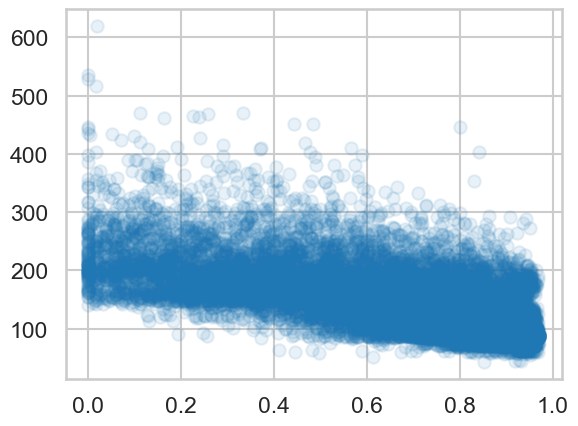

In [25]:
plt.scatter(df["pfemp_variant_frac"], df["duration"], alpha=0.1)

In [26]:
# bin pfemp_variant_frac column into bins of size 0.05, from 0 to 1
df["pfemp_variant_frac_bin"] = pd.cut(df["pfemp_variant_frac"], np.arange(0, 1.05, 0.2))

meta NOT subset; don't know how to subset; dropped


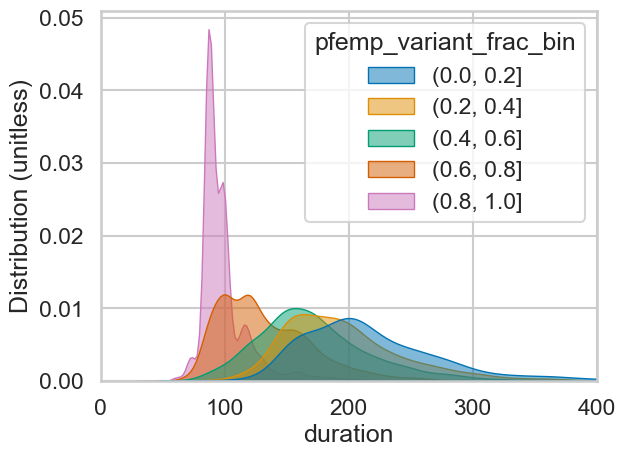

In [30]:
# use coloblind-friendly palette
# palette = "crest"
palette = sns.color_palette("colorblind", 5)
sns.kdeplot(
   data=df, x="duration", hue="pfemp_variant_frac_bin",
   fill=True, common_norm=False, palette=palette,
   alpha=.5, linewidth=1,
)

plt.xlim([0,400])
plt.ylabel("Distribution (unitless)")
# change legend title
# plt.legend(title="PfEMP1 variant fraction")
plt.savefig("infection_duration_distribution.png")
plt.savefig("infection_duration_distribution.pdf")

In [31]:
df["log_total_gametocyte_density"] = np.log10(df["total_gametocyte_density"])

meta NOT subset; don't know how to subset; dropped


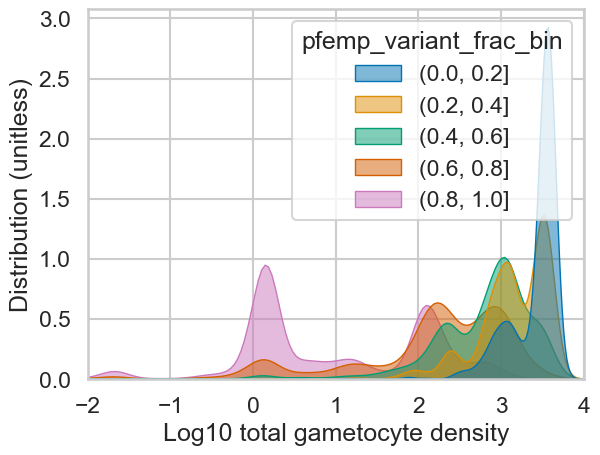

In [32]:
sns.kdeplot(
   data=df, x="log_total_gametocyte_density", hue="pfemp_variant_frac_bin",
   fill=True, common_norm=False, palette=palette,
   alpha=.5, linewidth=1,
)

# plt.xlim([0,400])
plt.xlim([-2,4])
plt.ylabel("Distribution (unitless)")
plt.xlabel("Log10 total gametocyte density")
# change legend title
# plt.legend(title="PfEMP1 variant fraction")
plt.savefig("total_gametocytes_distribution.png")
plt.savefig("total_gametocytes_distribution.pdf")

In [6]:
def age_based_surface_area(age_in_years):
    # piecewise linear rising from birth to age 2
    # and then shallower slope to age 20
    newborn_risk = 0.07
    two_year_old_risk = 0.23
    if age_in_years < 2:
        return newborn_risk + age_in_years * (two_year_old_risk - newborn_risk) / 2

    if age_in_years < 20:
        return two_year_old_risk + (age_in_years - 2) * (1 - two_year_old_risk) / ((20 - 2))

    return 1.

def predict_emod_pfemp1_variant_fraction(age_in_years, relative_biting_risk, daily_sim_eir):
    # Predict equilibrium immunity level that EMOD would give based on age, relative biting rate, and daily simulated EIR
    # From logistic function fit across EMOD sweep
    # see C:\Users\joshsu\OneDrive - Bill & Melinda Gates Foundation\Code\emod-network-testing\analysis\240520\summarize_emod_infections.ipynb

    # Note: relative_biting_rate is a factor that scales the biting rate for each individual compared to the mean
    
    absa_vectorized = np.vectorize(age_based_surface_area)

    # Impose minimum on daily_sim_eir
    daily_sim_eir = np.maximum(daily_sim_eir, 1e-5)

    if np.sum(age_in_years <= 0) > 0 or np.sum(relative_biting_risk <= 0) > 0 or np.sum(daily_sim_eir <= 0) > 0:
        raise ValueError("Age, relative_biting_rate, and daily_sim_eir must be positive")

    individual_daily_eir = daily_sim_eir * relative_biting_risk * absa_vectorized(age_in_years)

    # a = 1.933115996606731
    # b = 0.8970967578560122
    # c = 0.8991575730911449
    # d = -1.441447182704689

    # return 1 / (1 + np.exp(-(a * np.log(age_in_years) +
    #                          b * np.log(relative_biting_rate) +
    #                          c * np.log(daily_sim_eir) +
    #                          d)))
    a = 1.516316521864015
    b = 0.8930658890703256
    c = -0.042777966215856424

    return 1 / (1 + np.exp(-(a * np.log(age_in_years) +
                             b * np.log(individual_daily_eir) +
                             c)))

In [7]:
aeir = 10
predict_emod_pfemp1_variant_fraction(10, 1, aeir/365)

0.43474893752689847

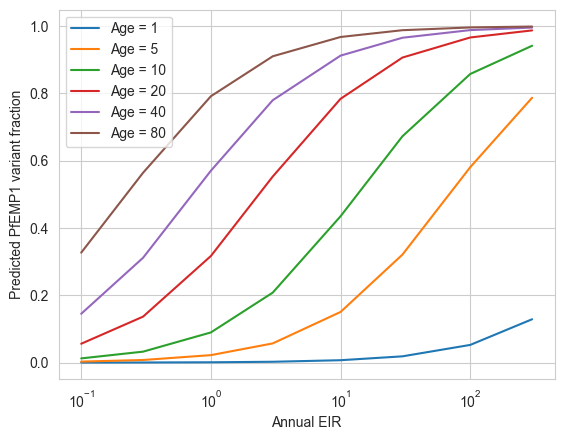

In [8]:
aeir = np.array([0.1,0.3,1,3,10,30,100,300])
ages = [1,5,10,20,40,80]

for age in ages:
    plt.plot(aeir, predict_emod_pfemp1_variant_fraction(age, 1, aeir/365), label="Age = {}".format(age))
plt.xscale("log")
plt.xlabel("Annual EIR")
plt.ylabel("Predicted PfEMP1 variant fraction")
plt.legend()
